# RevenueIQ — Exploratory Data Analysis & Model Development

This notebook walks through the full analysis pipeline:
1. Load & clean raw sales data
2. Exploratory Data Analysis (EDA)
3. Feature engineering
4. Model development & evaluation:
   - Revenue forecasting (Gradient Boosting Regressor)
   - Product/region segmentation (K-Means + RFM features)
   - Order-level anomaly detection (Isolation Forest)
5. Save trained models for use in the Streamlit app

**Note:** This notebook uses the synthetic sample dataset generated by
`src/data/generate_sample_data.py`. Swap in your own CSV (matching the
schema below) by changing `RAW_DATA_PATH`.


In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.make_dataset import load_and_clean
from src.features.build_features import (
    build_forecasting_features, build_product_features,
    build_customer_like_features, add_order_level_anomaly_features
)
from src.models.forecast_model import SalesForecaster
from src.models.segmentation_model import run_segmentation
from src.models.anomaly_model import AnomalyDetector

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

RAW_DATA_PATH = "../data/raw/sales_data.csv"


## 1. Load & Clean Data

Required schema: `Order ID, Date, Category, Product Name, Quantity, Unit Price, Total Price, Region, Payment Method`


In [2]:
df = load_and_clean(RAW_DATA_PATH)
print(df.shape)
df.head()

2026-06-19 19:38:18,793 | INFO | Loading raw data from ../data/raw/sales_data.csv


2026-06-19 19:38:18,868 | INFO | Cleaned dataset: 6,000 rows, 2023-01-01 to 2024-12-31


(6000, 15)


,Order ID,Date,Category,Product Name,Quantity,Unit Price,Total Price,Region,Payment Method,Year,Month,Day,DayOfWeek,WeekOfYear,IsWeekend
0,ORD12269,2023-01-01,Clothing,Wool Sweater,6,3312.47,19874.82,North America,Credit Card,2023,1,1,6,52,1
1,ORD13941,2023-01-01,Sports,Dumbbell Set,5,3122.84,15614.20,North America,Credit Card,2023,1,1,6,52,1
2,ORD14415,2023-01-01,Beauty Products,Sunscreen SPF50,2,233.44,466.88,Africa,Debit Card,2023,1,1,6,52,1
3,ORD15200,2023-01-01,Books,Self-Help Guide,3,559.72,1679.16,Australia,UPI,2023,1,1,6,52,1
4,ORD15596,2023-01-01,Clothing,Formal Shirt,6,3473.57,20841.42,North America,Debit Card,2023,1,1,6,52,1


In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Order ID,6000,6000,ORD12269,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,6000,NaN,NaN,NaN,2023-12-27 14:10:48,2023-01-01 00:00:00,2023-06-26 00:00:00,2023-12-29 00:00:00,2024-06-26 00:00:00,2024-12-31 00:00:00,NaN
Category,6000,6,Beauty Products,1052,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product Name,6000,30,Office Chair,231,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,6000.0,NaN,NaN,NaN,3.686667,1.0,1.0,2.0,4.0,53.0,6.44234
Unit Price,6000.0,NaN,NaN,NaN,3555.843418,150.97,928.365,2213.835,5043.21,14983.3,3498.16688
Total Price,6000.0,NaN,NaN,NaN,13481.027187,152.86,1966.8,4917.39,12004.655,763368.51,37595.327121
Region,6000,6,South America,1037,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Payment Method,6000,5,Credit Card,2127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,6000.0,NaN,NaN,NaN,2023.495833,2023.0,2023.0,2023.0,2024.0,2024.0,0.500024


## 2. Exploratory Data Analysis

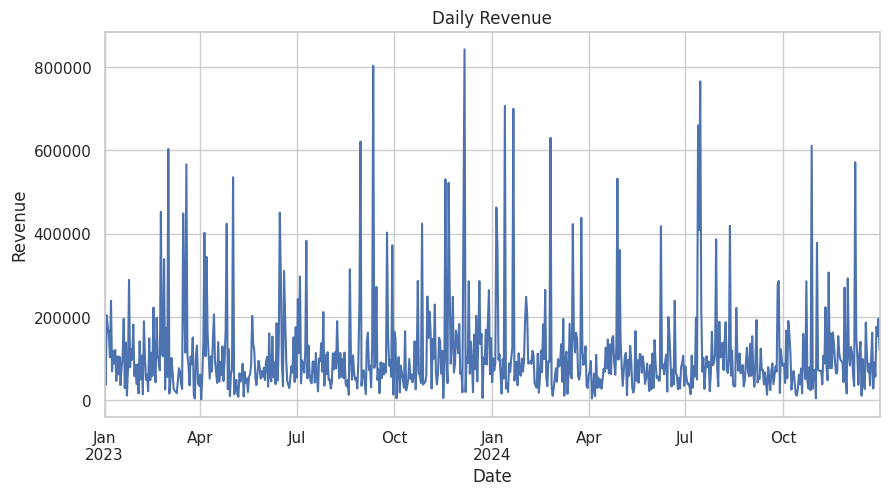

In [4]:
# Revenue over time
daily = df.set_index("Date").resample("D")["Total Price"].sum()
daily.plot(title="Daily Revenue", ylabel="Revenue")
plt.show()

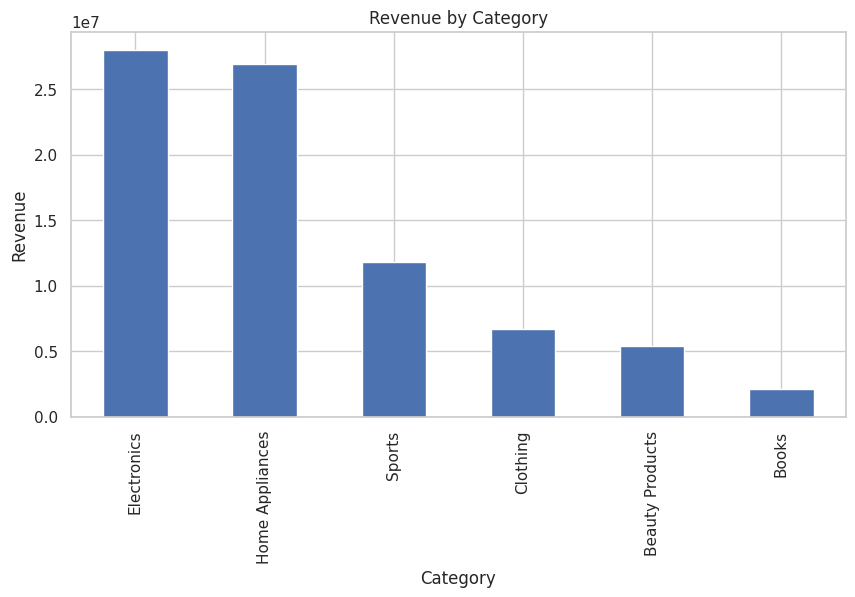

In [5]:
# Revenue by category
cat_rev = df.groupby("Category")["Total Price"].sum().sort_values(ascending=False)
cat_rev.plot(kind="bar", title="Revenue by Category")
plt.ylabel("Revenue")
plt.show()

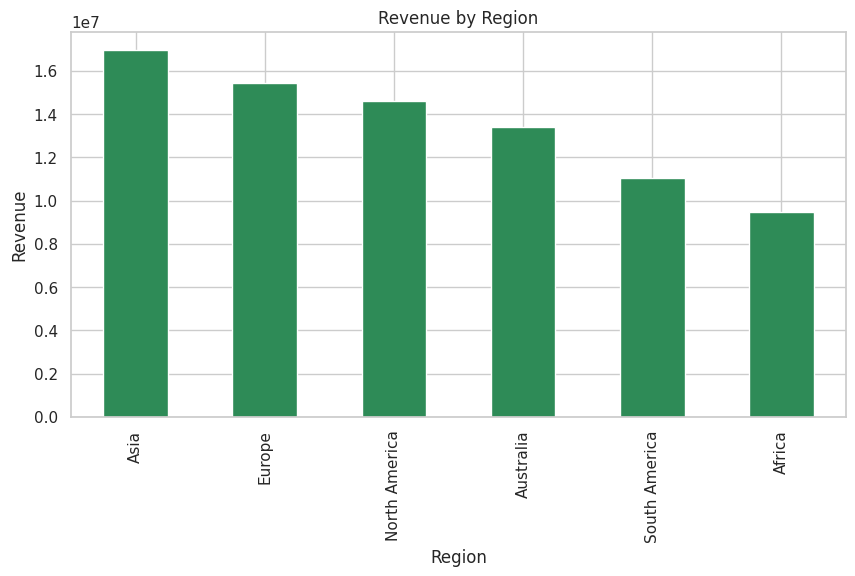

In [6]:
# Revenue by region
region_rev = df.groupby("Region")["Total Price"].sum().sort_values(ascending=False)
region_rev.plot(kind="bar", color="seagreen", title="Revenue by Region")
plt.ylabel("Revenue")
plt.show()

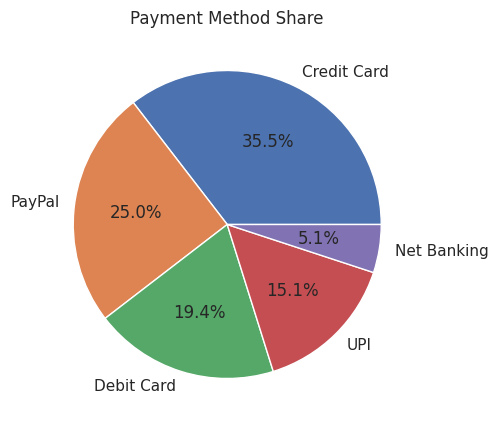

In [7]:
# Payment method distribution
df["Payment Method"].value_counts().plot(kind="pie", autopct="%1.1f%%", title="Payment Method Share")
plt.ylabel("")
plt.show()

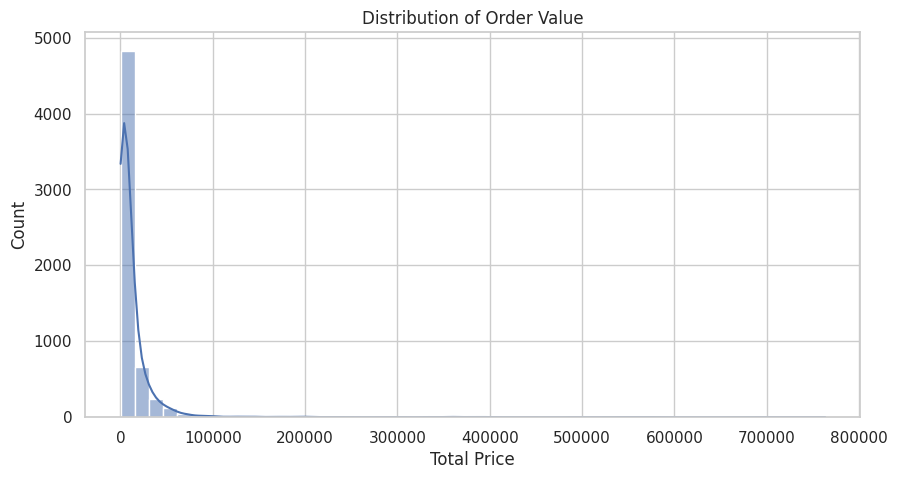

In [8]:
# Order value distribution
sns.histplot(df["Total Price"], bins=50, kde=True)
plt.title("Distribution of Order Value")
plt.show()

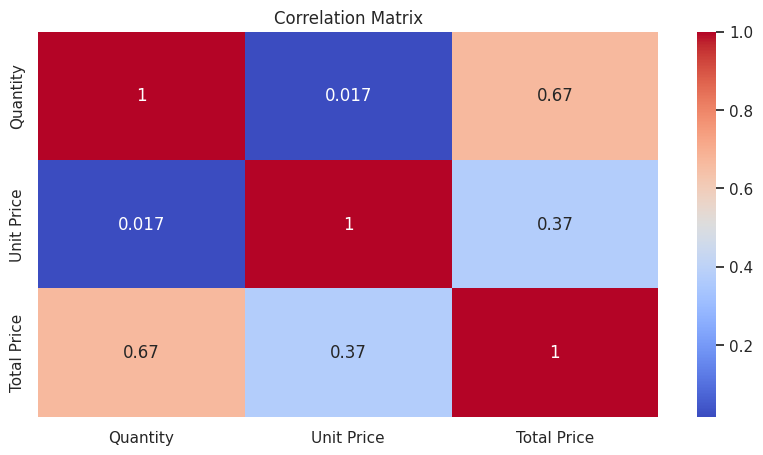

In [9]:
# Correlation between numeric features
numeric_cols = ["Quantity", "Unit Price", "Total Price"]
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## 3. Feature Engineering

Build the feature sets used by each downstream model.

In [10]:
ts_features = build_forecasting_features(df, freq="D")
ts_features.tail()

,Date,Revenue,Units,Orders,DayOfWeek,Month,Day,WeekOfYear,IsWeekend,IsMonthStart,...,Revenue_lag_1,Revenue_lag_7,Revenue_lag_14,Revenue_lag_30,Revenue_roll_mean_7,Revenue_roll_std_7,Revenue_roll_mean_14,Revenue_roll_std_14,Revenue_roll_mean_30,Revenue_roll_std_30
726,2024-12-27,57109.38,21,5,4,12,27,52,0,0,...,90994.63,68998.28,140623.90,43515.22,81466.715714,44565.743950,84964.742857,53211.433610,112689.189000,109801.702820
727,2024-12-28,176879.65,39,13,5,12,28,52,1,0,...,57109.38,88173.86,11584.99,270613.50,79768.301429,45339.936111,78999.420000,51132.350937,113142.327667,109534.110805
728,2024-12-29,155156.85,21,7,6,12,29,52,1,0,...,176879.65,35736.78,99433.91,59502.49,92440.557143,58552.137723,90806.181429,53401.933483,110017.866000,106172.652136
729,2024-12-30,196510.83,36,9,0,12,30,1,0,0,...,155156.85,95540.42,43097.62,16752.35,109500.567143,56643.364499,94786.391429,56102.753490,113206.344667,106039.527855
730,2024-12-31,120761.68,29,9,1,12,31,1,0,0,...,196510.83,162296.47,27306.63,292894.40,123924.911429,64769.196162,105744.477857,60072.240764,119198.294000,105478.584695


In [11]:
product_features = build_product_features(df)
product_features.sort_values("TotalRevenue", ascending=False).head(10)

,Product Name,TotalRevenue,TotalUnits,AvgUnitPrice,OrderCount,LastOrderDate,FirstOrderDate,RecencyDays,ActiveDays,AvgRevenuePerOrder,PurchaseFrequency
27,Wireless Mouse,6874211.55,795,8038.661290,217,2024-12-29,2023-01-04,3,726,31678.394240,0.298898
1,Bluetooth Speaker,5944108.17,779,7461.296419,215,2024-12-12,2023-01-02,20,711,27647.014744,0.302391
26,Vacuum Cleaner,5745194.65,856,6705.244071,226,2024-12-28,2023-01-04,4,725,25421.215265,0.311724
0,Air Fryer,5710091.91,736,7064.720739,203,2024-12-30,2023-01-03,2,728,28128.531576,0.278846
24,Table Lamp,5510952.41,797,6470.556432,185,2024-12-31,2023-01-01,1,731,29788.931946,0.253078
12,Laptop Stand,5458305.83,676,7217.293392,171,2024-12-30,2023-01-05,2,726,31919.917135,0.235537
22,Smartwatch,5195892.87,666,7837.277436,195,2024-12-31,2023-01-04,1,728,26645.604462,0.267857
16,Office Chair,5054371.98,736,6426.537359,231,2024-12-31,2023-01-03,1,729,21880.398182,0.316872
14,Microwave Oven,4907315.88,771,6429.827806,196,2024-12-29,2023-01-01,3,729,25037.325918,0.268861
25,USB-C Hub,4500468.72,602,7465.293817,186,2024-12-18,2023-01-03,14,716,24196.068387,0.259777


## 4. Model Development

### 4.1 Revenue Forecasting (Gradient Boosting Regressor)

We frame forecasting as a supervised regression problem using lagged
revenue, rolling statistics, and calendar features.

In [12]:
forecaster = SalesForecaster()
metrics = forecaster.evaluate(ts_features, n_splits=4)
print("Cross-validated performance:")
for k, v in metrics.items():
    print(f"  {k}: {v}")

Cross-validated performance:
  MAE: 91968.17454066922
  MAPE: 1.6688978310659404
  R2: -0.5364124522622508
  n_splits: 4


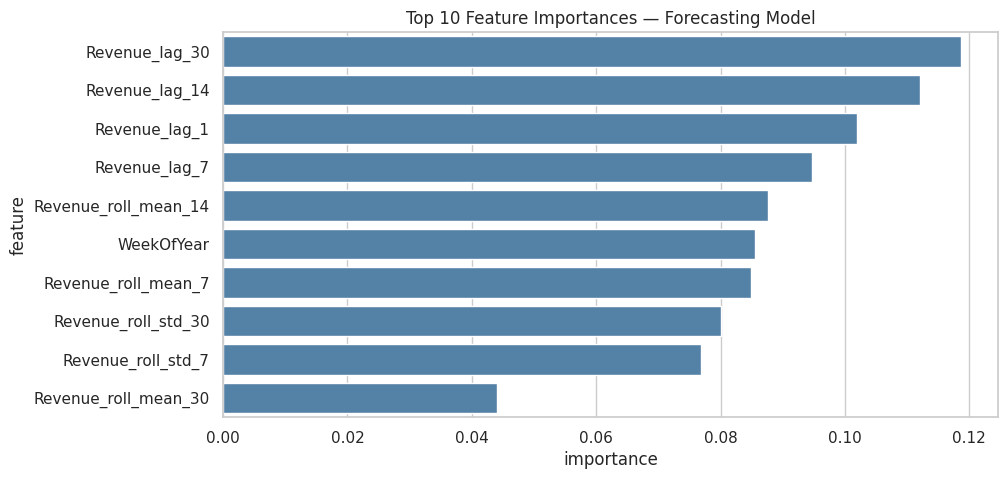

In [13]:
forecaster.fit(ts_features)

importances = forecaster.feature_importances()
sns.barplot(data=importances.head(10), x="importance", y="feature", color="steelblue")
plt.title("Top 10 Feature Importances — Forecasting Model")
plt.show()

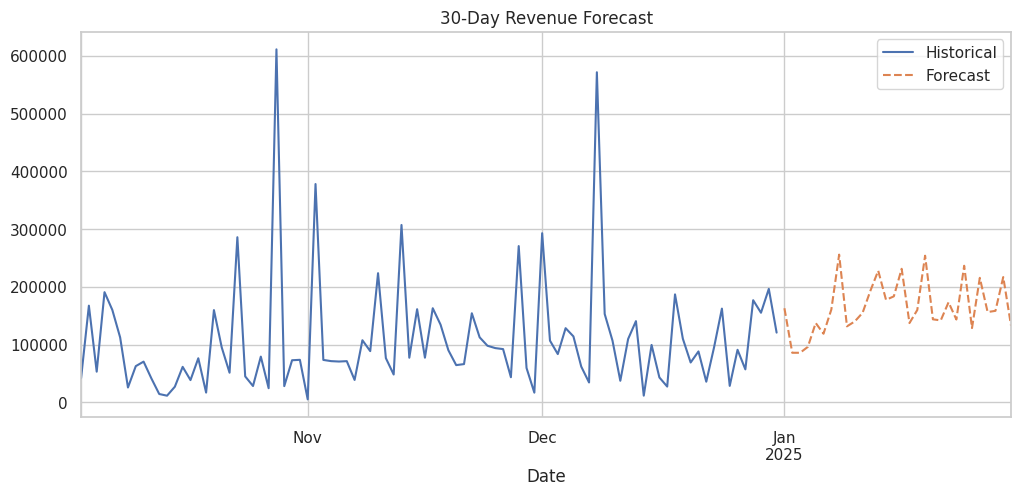

In [14]:
future = forecaster.forecast_future(ts_features, horizon=30)

fig, ax = plt.subplots(figsize=(12, 5))
ts_features.set_index("Date")["Revenue"].tail(90).plot(ax=ax, label="Historical")
future.set_index("Date")["Revenue"].plot(ax=ax, label="Forecast", linestyle="--")
ax.legend()
ax.set_title("30-Day Revenue Forecast")
plt.show()

In [15]:
# Save the trained forecasting model
forecaster.save("../models/forecast_model.joblib")

2026-06-19 19:38:23,968 | INFO | Saved forecasting model -> ../models/forecast_model.joblib


### 4.2 Product Segmentation (K-Means + RFM)

We cluster products using Recency, Frequency, and Monetary (RFM-style)
features, automatically selecting K via silhouette score.

In [16]:
seg_model, seg_result = run_segmentation(df, level="product")
print(f"Selected K = {seg_model.k}")
seg_result.sort_values("TotalRevenue", ascending=False)

2026-06-19 19:38:24,025 | INFO | k=2 -> silhouette=0.3118


2026-06-19 19:38:24,038 | INFO | k=3 -> silhouette=0.2816


2026-06-19 19:38:24,050 | INFO | k=4 -> silhouette=0.3395


2026-06-19 19:38:24,063 | INFO | k=5 -> silhouette=0.2857


2026-06-19 19:38:24,077 | INFO | k=6 -> silhouette=0.3449


Selected K = 6


,Product Name,TotalRevenue,TotalUnits,AvgUnitPrice,OrderCount,LastOrderDate,FirstOrderDate,RecencyDays,ActiveDays,AvgRevenuePerOrder,PurchaseFrequency,Cluster,SegmentRank,Segment
27,Wireless Mouse,6874211.55,795,8038.661290,217,2024-12-29,2023-01-04,3,726,31678.394240,0.298898,0,5,Top Performer
1,Bluetooth Speaker,5944108.17,779,7461.296419,215,2024-12-12,2023-01-02,20,711,27647.014744,0.302391,2,3,Above Average
26,Vacuum Cleaner,5745194.65,856,6705.244071,226,2024-12-28,2023-01-04,4,725,25421.215265,0.311724,0,5,Top Performer
0,Air Fryer,5710091.91,736,7064.720739,203,2024-12-30,2023-01-03,2,728,28128.531576,0.278846,4,4,High Value
24,Table Lamp,5510952.41,797,6470.556432,185,2024-12-31,2023-01-01,1,731,29788.931946,0.253078,4,4,High Value
12,Laptop Stand,5458305.83,676,7217.293392,171,2024-12-30,2023-01-05,2,726,31919.917135,0.235537,4,4,High Value
22,Smartwatch,5195892.87,666,7837.277436,195,2024-12-31,2023-01-04,1,728,26645.604462,0.267857,4,4,High Value
16,Office Chair,5054371.98,736,6426.537359,231,2024-12-31,2023-01-03,1,729,21880.398182,0.316872,0,5,Top Performer
14,Microwave Oven,4907315.88,771,6429.827806,196,2024-12-29,2023-01-01,3,729,25037.325918,0.268861,4,4,High Value
25,USB-C Hub,4500468.72,602,7465.293817,186,2024-12-18,2023-01-03,14,716,24196.068387,0.259777,2,3,Above Average


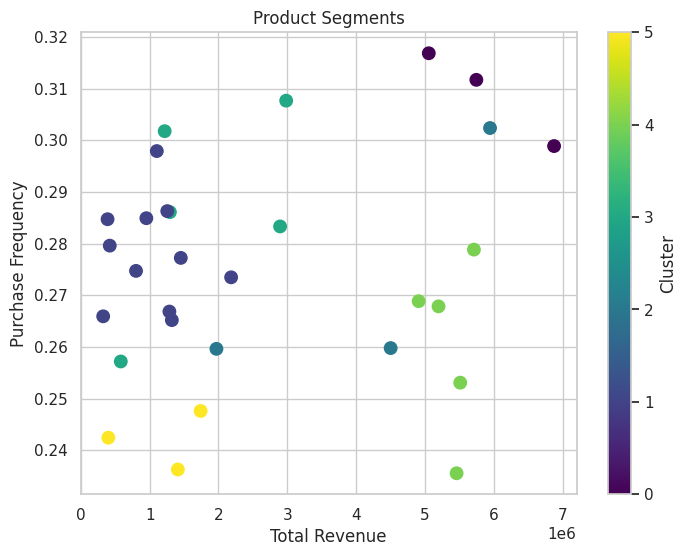

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    seg_result["TotalRevenue"], seg_result["PurchaseFrequency"],
    c=seg_result["Cluster"], cmap="viridis", s=80
)
ax.set_xlabel("Total Revenue")
ax.set_ylabel("Purchase Frequency")
ax.set_title("Product Segments")
plt.colorbar(scatter, label="Cluster")
plt.show()

In [18]:
seg_model.save("../models/segmentation_model.joblib")

2026-06-19 19:38:24,353 | INFO | Saved segmentation model -> ../models/segmentation_model.joblib


### 4.3 Anomaly Detection (Isolation Forest)

Flags orders that deviate from typical price/quantity patterns within
their category — useful for catching data entry errors or unusually
large bulk orders worth investigating.

In [19]:
detector = AnomalyDetector(contamination=0.02)
anomaly_result = detector.fit_predict(df)

n_anomalies = anomaly_result["IsAnomaly"].sum()
print(f"Flagged {n_anomalies} anomalies out of {len(df)} orders ({n_anomalies/len(df):.1%})")

anomaly_result[anomaly_result["IsAnomaly"]][
    ["Order ID", "Date", "Category", "Product Name", "Quantity", "Unit Price", "Total Price", "AnomalyScore"]
].head(10)

Flagged 120 anomalies out of 6000 orders (2.0%)


,Order ID,Date,Category,Product Name,Quantity,Unit Price,Total Price,AnomalyScore
2159,ORD15080,2023-09-11,Electronics,Laptop Stand,51,14968.01,763368.51,-0.127709
3188,ORD14354,2024-01-21,Electronics,Bluetooth Speaker,45,14316.49,644242.05,-0.116001
3478,ORD12692,2024-02-25,Electronics,Wireless Mouse,48,12238.89,587466.72,-0.103344
3134,ORD10069,2024-01-13,Electronics,Wireless Mouse,41,13826.11,566870.51,-0.102867
5472,ORD12033,2024-10-28,Electronics,Laptop Stand,43,13444.53,578114.79,-0.101692
4621,ORD14986,2024-07-13,Home Appliances,Air Fryer,48,11857.92,569180.16,-0.098713
4636,ORD15691,2024-07-15,Home Appliances,Office Chair,51,10946.63,558278.13,-0.092159
2058,ORD14073,2023-08-30,Home Appliances,Table Lamp,51,10990.48,560514.48,-0.090496
483,ORD13522,2023-02-26,Sports,Cricket Bat,51,5784.75,295022.25,-0.084078
659,ORD15484,2023-03-19,Home Appliances,Microwave Oven,45,8454.22,380439.90,-0.081415


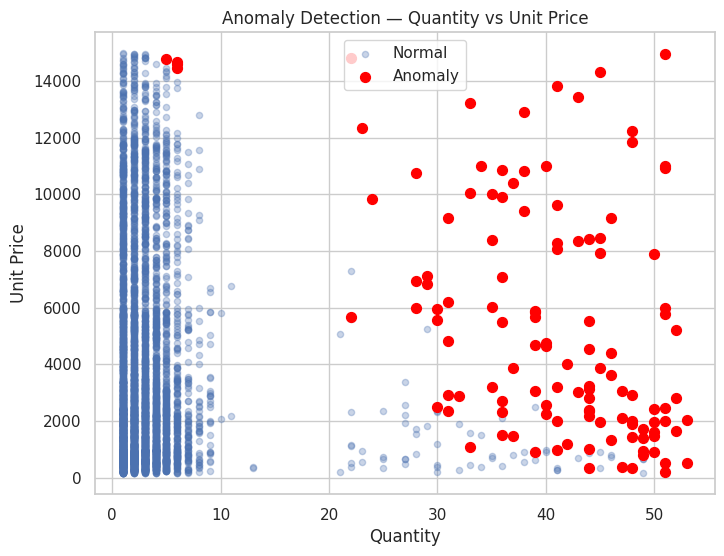

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
normal = anomaly_result[~anomaly_result["IsAnomaly"]]
anomalous = anomaly_result[anomaly_result["IsAnomaly"]]

ax.scatter(normal["Quantity"], normal["Unit Price"], alpha=0.3, label="Normal", s=20)
ax.scatter(anomalous["Quantity"], anomalous["Unit Price"], color="red", label="Anomaly", s=50)
ax.set_xlabel("Quantity")
ax.set_ylabel("Unit Price")
ax.set_title("Anomaly Detection — Quantity vs Unit Price")
ax.legend()
plt.show()

In [21]:
detector.save("../models/anomaly_model.joblib")

2026-06-19 19:38:25,478 | INFO | Saved anomaly detection model -> ../models/anomaly_model.joblib


## 5. Summary

| Model | Technique | Purpose |
|---|---|---|
| Forecasting | Gradient Boosting Regressor | Predict future daily revenue |
| Segmentation | K-Means (silhouette-selected K) | Group products/regions by value tier |
| Anomaly Detection | Isolation Forest | Flag unusual orders for review |

All trained models are saved to `../models/` and consumed directly by
the Streamlit app (`app/app.py`) for live, interactive predictions.
